In [ ]:
from google.colab import files

uploaded = files.upload()  # Choose your Indian Pines .mat files



Saving Indian_pines_gt.mat to Indian_pines_gt (11).mat
Saving Indian_pines_corrected.mat to Indian_pines_corrected (11).mat


In [ ]:
# IMPORTATION DES BIBLIOTHÈQUES
# =============================================================================
import scipy.io as sio  # Pour lire les fichiers .mat (format de données MATLAB).
import numpy as np      # Pour les calculs numériques et la manipulation de tableaux.
import torch            # Bibliothèque principale pour le Deep Learning (PyTorch).
import torch.nn as nn   # Contient les briques pour construire des réseaux de neurones (couches, fonctions de perte...).
import torch.nn.functional as F # Contient les fonctions d'activation (comme ReLU).
import torch.optim as optim     # Contient les algorithmes d'optimisation (comme Adam).
from torch.utils.data import TensorDataset, DataLoader # Outils pour gérer les données en lots (batches).
from sklearn.preprocessing import MinMaxScaler         # Pour normaliser les données.
from sklearn.model_selection import train_test_split   # Pour diviser les données en ensembles d'entraînement et de test.

In [ ]:
# 1 : CHARGEMENT ET PRÉTRAITEMENT DES DONNÉES
# =============================================================================
# 'data' est le cube hyperspectral (image), 'gt' est la carte de vérité terrain (labels).
data = sio.loadmat('Indian_pines_corrected.mat')['indian_pines_corrected']
gt = sio.loadmat('Indian_pines_gt.mat')['indian_pines_gt']

# --- Normalisation des données ---
# La normalisation est cruciale pour que le réseau de neurones apprenne efficacement.
# Elle met toutes les bandes spectrales sur la même échelle de valeurs [0, 1].

# 1. Aplatir l'image : Le normalisateur attend un tableau 2D (nombre_de_pixels, nombre_de_caractéristiques).
#    Ici, chaque pixel est un échantillon et chaque bande spectrale est une caractéristique.
data_reshaped = data.reshape(-1, data.shape[2]) # Forme : (145*145, 200)

# 2. Appliquer la normalisation Min-Max
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_reshaped)

# 3. Redonner à l'image sa forme 3D d'origine
data = data_normalized.reshape(data.shape) # Forme : (145, 145, 200)

In [ ]:
# 2 : EXTRACTION DES PATCHS (VIGNETTES)
# =============================================================================
# On va extraire des "patchs" (petites images) de taille 11x11 autour de chaque pixel étiqueté.

PATCH_SIZE = 11
PADDING = PATCH_SIZE // 2

def pad_with_zeros(X, margin):
    # Ajoute un rembourrage de zéros sur les dimensions spatiales (ZerosPadding)
    return np.pad(X, ((margin, margin), (margin, margin), (0, 0)), mode='constant')

padded_data = pad_with_zeros(data, PADDING)

patches = []
labels = []


rows, cols = gt.shape
for r in range(rows):
    for c in range(cols):
        label = gt[r, c]
        # On ne s'intéresse qu'aux pixels qui ont une étiquette (label > 0).
        if label == 0:
            continue

        # Extraire le patch 11x11 depuis l'image 'paddée' (rembourrée)
        patch = padded_data[r:r + PATCH_SIZE, c:c + PATCH_SIZE, :]
        patches.append(patch)

        # Les labels dans 'gt' vont de 1 à 16. PyTorch attend des labels de 0 à 15.
        # On soustrait donc 1 à chaque label.
        labels.append(label - 1)

# Convertir les listes en tableaux NumPy pour la manipulation
patches = np.array(patches)
labels = np.array(labels)

In [ ]:
# 3 : PRÉPARATION DES DONNÉES POUR PYTORCH
# =============================================================================
# Diviser les données en un ensemble d'entraînement (70%) et un ensemble de test (30%).
# 'stratify=labels' garantit que la proportion de chaque classe est la même
# dans les deux ensembles
# 'random_state=1' assure que la division est toujours la même, pour la reproductibilité.
X_train, X_test, y_train, y_test = train_test_split(
    patches, labels, test_size=0.3, random_state=1, stratify=labels
)

# Convertir les données NumPy en tenseurs PyTorch.
# Les CNN 2D de PyTorch attendent des données au format : (N, C, H, W)
# N: Nombre d'échantillons (batch size)
# C: Nombre de canaux (channels), ici nos 200 bandes spectrales
# H: Hauteur du patch (Height)
# W: Largeur du patch (Width)
# Nos patchs sont actuellement en format (N, H, W, C), il faut donc permuter les axes.
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
# 4 : DÉFINITION DU MODÈLE CNN
# =============================================================================
class HSI2DCNN(nn.Module):
    def __init__(self, in_channels=200, num_classes=16):
        super(HSI2DCNN, self).__init__()

        # --- Bloc d'extraction de caractéristiques ---
        # 1ère couche de convolution : 200 canaux en entrée, 32 en sortie, noyau 3x3
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Normalisation pour stabiliser l'apprentissage
        # 2ème couche de convolution
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # 3ème couche de convolution
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # Couche de Pooling : réduit la taille spatiale de moitié (ex: 10x10 -> 5x5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Bloc de classification (Partie "Perceptron") ---
        # Calcul de la taille de l'entrée de la première couche linéaire (fully connected) :
        # Input: 11x11
        # Après conv1, conv2 -> 11x11 (car padding=1 et kernel=3)
        # Après 1er pool -> E(11/2) = 5 -> 5x5
        # Après conv3 -> 5x5
        # Après 2ème pool -> E(5/2) = 2 -> 2x2
        # Taille aplatie = 128 (canaux de sortie de conv3) * 2 * 2 = 512
        self.fc1 = nn.Linear(128 * 2 * 2, 256)

        # Le Dropout est une technique de régularisation pour éviter le surapprentissage.
        # Il "éteint" aléatoirement 50% des neurones à chaque passe d'entraînement.
        self.dropout = nn.Dropout(0.5)

        # Couche de sortie : 256 neurones en entrée, num_classes (16) en sortie.
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Propagation avant
        # Bloc 1
        x = F.relu(self.bn1(self.conv1(x)))
        # Bloc 2 + Pooling
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Bloc 3 + Pooling
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Aplatir le tenseur pour le passer aux couches linéaires
        # x.size(0) est la taille du batch. -1 demande à PyTorch de calculer la taille restante.
        x = x.view(x.size(0), -1)

        # Couches de classification
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Sortie finale
        return x

In [ ]:
# 5 : CONFIGURATION DE L'ENTRAÎNEMENT
# =============================================================================
# Hyperparamètres
num_epochs = 50       # Nombre de fois où l'on parcourt tout le jeu de données.
batch_size = 64       # Nombre d'échantillons traités en une seule fois.
learning_rate = 0.0001 # Pas d'apprentissage pour la mise à jour des poids.

# Créer une instance du modèle
model = HSI2DCNN(in_channels=200, num_classes=16)

# Fonction de perte (critère d'erreur)
# CrossEntropyLoss est standard pour la classification multi-classes.
# Elle combine une fonction Softmax et une perte NLL (Negative Log Likelihood).
criterion = nn.CrossEntropyLoss()

# Optimiseur
# Adam est un algorithme d'optimisation efficace qui ajuste le taux d'apprentissage.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Utiliser le GPU (processeur graphique) si disponible, sinon le CPU. L'entraînement est beaucoup plus rapide sur GPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du périphérique : {device}")
model.to(device) # Envoyer le modèle sur le périphérique choisi

# Créer les DataLoaders
# Ils gèrent les données en lots (batches) et permettent de les mélanger (shuffle).
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Pas besoin de mélanger pour le test

Utilisation du périphérique : cpu


In [ ]:
# 6 : FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION
# =============================================================================
def train(model, loader, criterion, optimizer):
    model.train() # Met le modèle en mode "entraînement" (active le dropout, etc.)
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        # Envoyer les données du batch sur le bon périphérique (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Réinitialiser les gradients à zéro avant chaque passe

        outputs = model(inputs) # Propagation avant
        loss = criterion(outputs, labels) # Calcul de l'erreur
        loss.backward() # Rétropropagation : calculer les gradients
        optimizer.step() # Mettre à jour les poids du réseau

        # Calcul des métriques pour suivre la performance
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1) # La classe prédite est celle avec le score le plus élevé
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total # perte moyenne
    epoch_acc = correct / total       # précision
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval() # Met le modèle en mode "évaluation" (désactive le dropout, etc.)
    running_loss = 0.0
    correct = 0
    total = 0

    # 'torch.no_grad()' désactive le calcul des gradients, ce qui accélère
    # l'évaluation et réduit l'utilisation de la mémoire.
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [ ]:
# 7 : BOUCLE D'ENTRAÎNEMENT PRINCIPALE
# =============================================================================
train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_acc = 0.0 # Pour suivre la meilleure précision de test obtenue

for epoch in range(1, num_epochs + 1):
    # Entraîner le modèle sur une époque
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    # Évaluer le modèle sur l'ensemble de test
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    # Sauvegarder les métriques pour les graphiques futurs
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoque {epoch:02d}/{num_epochs} | "
          f"Perte Entr: {train_loss:.4f}, Préc Entr: {train_acc:.4f} | "
          f"Perte Test: {test_loss:.4f}, Préc Test: {test_acc:.4f}")

    # Sauvegarder le modèle uniquement si sa performance sur le test s'est améliorée
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"-> Modèle sauvegardé (Préc Test: {best_acc:.4f})")

# Sauvegarder le modèle final (de la dernière époque)
torch.save(model.state_dict(), 'hsi_2dcnn_indian_pines_final.pth')
print("\nEntraînement terminé.")

Epoque 01/50 | Perte Entr: 1.6543, Préc Entr: 0.4806 | Perte Test: 1.2874, Préc Test: 0.5483
-> Modèle sauvegardé (Préc Test: 0.5483)
Epoque 02/50 | Perte Entr: 0.8811, Préc Entr: 0.7154 | Perte Test: 1.4944, Préc Test: 0.5899
-> Modèle sauvegardé (Préc Test: 0.5899)
Epoque 03/50 | Perte Entr: 0.5092, Préc Entr: 0.8502 | Perte Test: 0.9853, Préc Test: 0.6592
-> Modèle sauvegardé (Préc Test: 0.6592)
Epoque 04/50 | Perte Entr: 0.3129, Préc Entr: 0.9154 | Perte Test: 1.7001, Préc Test: 0.6657
-> Modèle sauvegardé (Préc Test: 0.6657)
Epoque 05/50 | Perte Entr: 0.2035, Préc Entr: 0.9455 | Perte Test: 0.4619, Préc Test: 0.8540
-> Modèle sauvegardé (Préc Test: 0.8540)
Epoque 06/50 | Perte Entr: 0.1339, Préc Entr: 0.9668 | Perte Test: 0.8370, Préc Test: 0.7662
Epoque 07/50 | Perte Entr: 0.1081, Préc Entr: 0.9739 | Perte Test: 0.4932, Préc Test: 0.8403
Epoque 08/50 | Perte Entr: 0.0706, Préc Entr: 0.9824 | Perte Test: 3.6701, Préc Test: 0.5330
Epoque 09/50 | Perte Entr: 0.1006, Préc Entr: 0.973

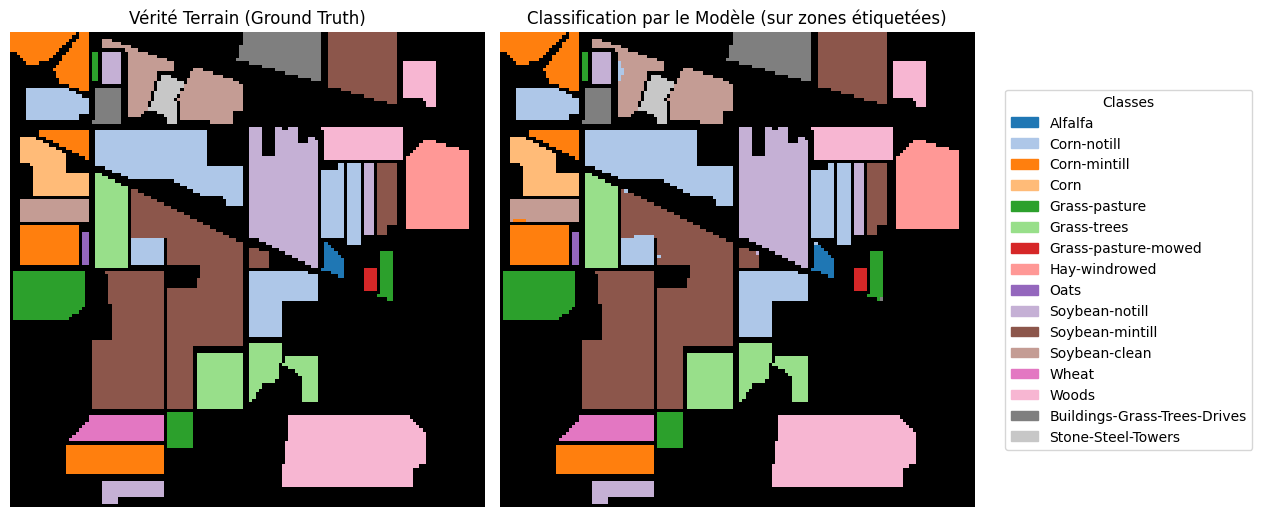

In [ ]:
# PRÉDICTION SUR L'IMAGE COMPLÈTE ET VISUALISATION
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Charger le meilleur modèle sauvegardé
# Il est crucial de recréer la même architecture avant de charger les poids.
model_loaded = HSI2DCNN(in_channels=200, num_classes=16)
model_loaded.load_state_dict(torch.load('best_model.pth')) # Charger les poids
model_loaded.to(device) # L'envoyer sur le bon périphérique
model_loaded.eval() # Le mettre en mode évaluation

def predict_full_image(model, data_cube, patch_size, device):
    #Utilise une approche de "fenêtre glissante" pour prédire la classe de chaque pixel de l'image.
    model.eval()
    pad = patch_size // 2
    # Appliquer le même padding que pour l'entraînement
    padded_data = np.pad(data_cube, ((pad, pad), (pad, pad), (0, 0)), mode='constant')
    H, W, _ = data_cube.shape
    # Créer une carte vide pour stocker les prédictions
    prediction_map = np.zeros((H, W), dtype=np.uint8)

    with torch.no_grad():
        for r in range(H):
            for c in range(W):
                # Extraire le patch pour le pixel (r, c)
                patch = padded_data[r:r + patch_size, c:c + patch_size, :]

                # Le transformer en tenseur PyTorch avec le bon format (1, C, H, W)
                # 'unsqueeze(0)' ajoute la dimension du batch (taille 1)
                patch_tensor = torch.tensor(patch, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
                patch_tensor = patch_tensor.to(device)

                # Obtenir la prédiction du modèle
                output = model(patch_tensor)
                predicted_class = output.argmax(dim=1).item()

                # Stocker la prédiction dans la carte. On ajoute 1 pour correspondre
                # au format des labels de la vérité terrain (1-16).
                prediction_map[r, c] = predicted_class + 1

    return prediction_map

# Générer la carte de classification prédite pour toute l'image
predicted_map = predict_full_image(model_loaded, data, patch_size=PATCH_SIZE, device=device)

# --- Affichage des résultats ---

# Définir les noms des classes pour la légende
class_names = [
    'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees',
    'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
    'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers'
]

# Créer une palette de couleurs. On ajoute 'black' pour la classe 0 (non étiquetée).
colors = ['black'] + list(plt.cm.tab20.colors[:16])
cmap = ListedColormap(colors)
norm = plt.Normalize(vmin=0, vmax=16) # Normalise les valeurs des classes pour la colormap

plt.figure(figsize=(15, 7))

# 1. Affichage de la vérité terrain (Ground Truth)
plt.subplot(1, 2, 1)
plt.imshow(gt, cmap=cmap, norm=norm)
plt.title('Vérité Terrain (Ground Truth)')
plt.axis('off')

# 2. Affichage de l'image prédite
prediction_masked = np.copy(predicted_map)
prediction_masked[gt == 0] = 0 # Mettre en noir les pixels non étiquetés
plt.subplot(1, 2, 2)
plt.imshow(prediction_masked, cmap=cmap, norm=norm)
plt.title('Classification par le Modèle (sur zones étiquetées)')
plt.axis('off')

# 3. Création de la légende pour les classes
handles = [mpatches.Patch(color=cmap.colors[i+1], label=class_names[i]) for i in range(len(class_names))]
plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1.05, 0.5), title="Classes")

# Ajuster la mise en page pour que la légende ne soit pas coupée
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

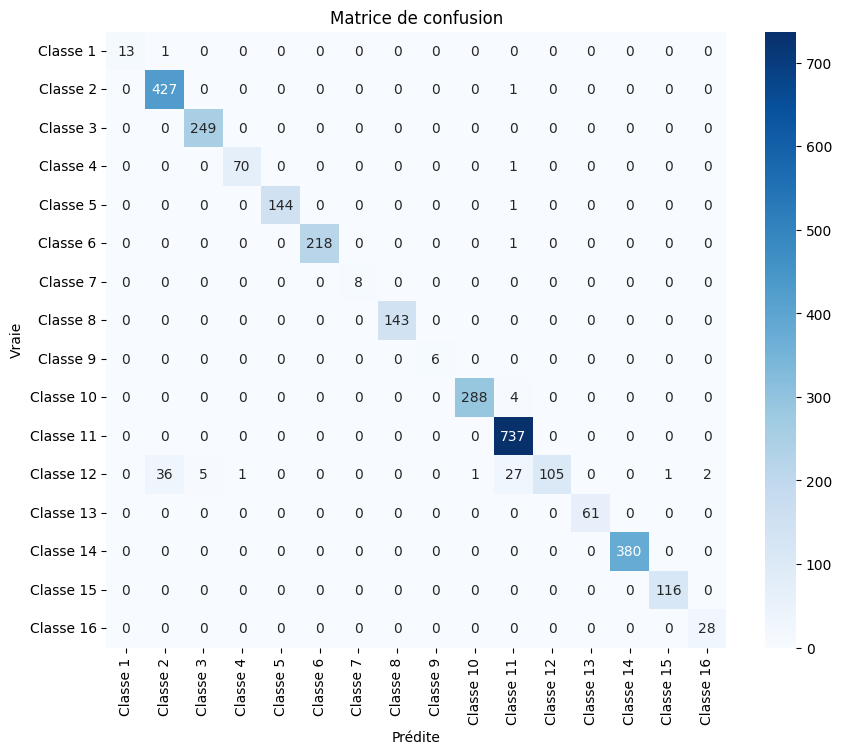

In [ ]:
# MATRICE DE CONFUSION
# =============================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculer les predicitions sur les tests
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Classe {i+1}' for i in range(16)],
            yticklabels=[f'Classe {i+1}' for i in range(16)])
plt.xlabel('Prédite')
plt.ylabel('Vraie')
plt.title('Matrice de confusion')
plt.show()

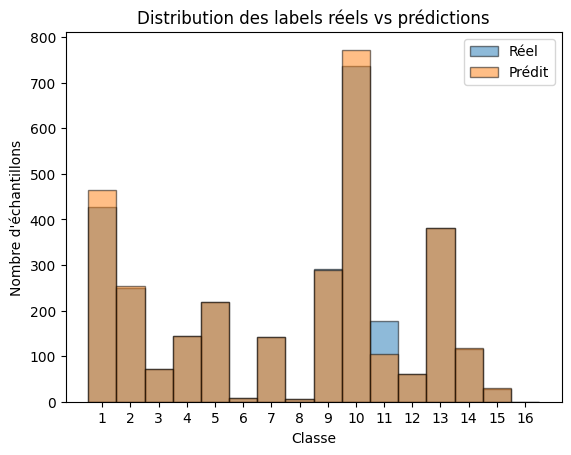

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.hist(all_labels, bins=np.arange(1, 18)-0.5, alpha=0.5, label='Réel', edgecolor='black')
plt.hist(all_preds, bins=np.arange(1, 18)-0.5, alpha=0.5, label='Prédit', edgecolor='black')
plt.xticks(range(1, 17))
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.title('Distribution des labels réels vs prédictions')
plt.legend()
plt.show()


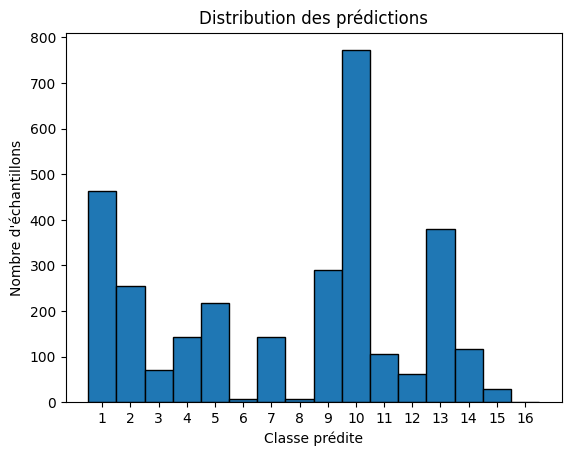

In [ ]:
plt.hist(all_preds, bins=np.arange(1, 18)-0.5, edgecolor='black')
plt.xticks(range(1, 17))
plt.xlabel('Classe prédite')
plt.ylabel('Nombre d\'échantillons')
plt.title('Distribution des prédictions')
plt.show()


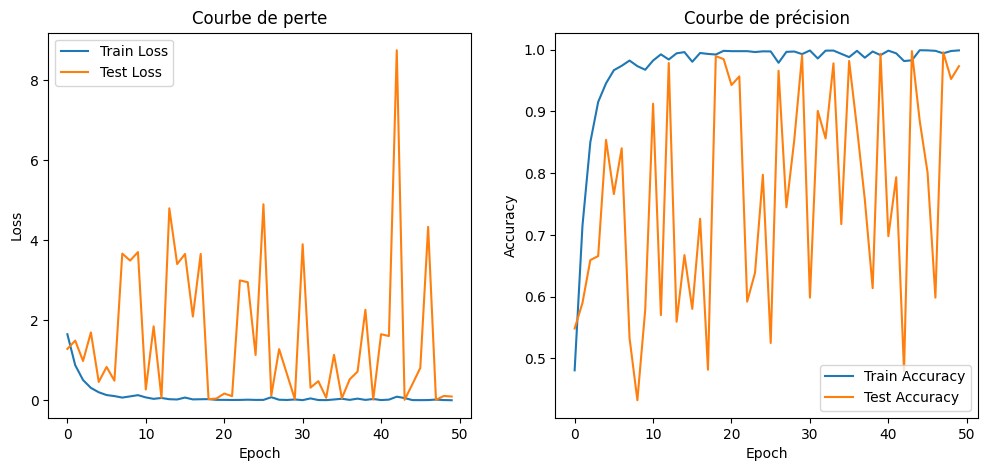

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Courbe de perte')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Courbe de précision')

plt.show()

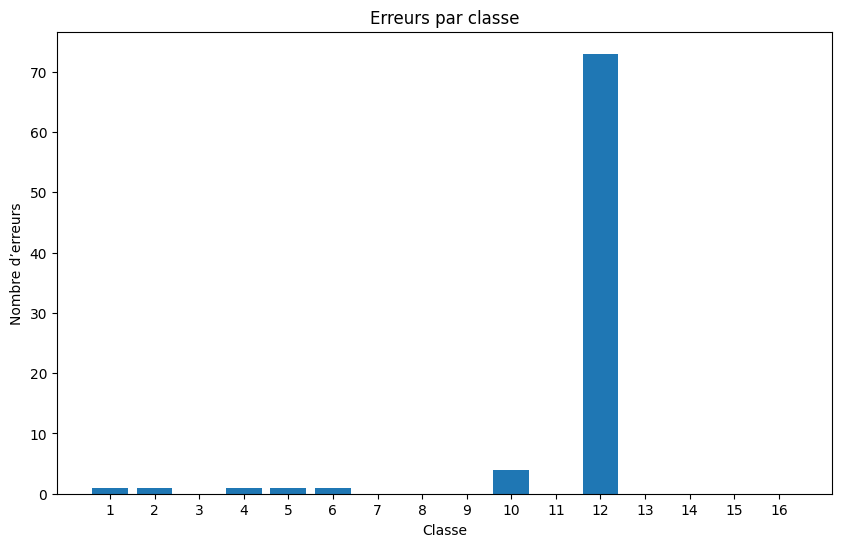

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_preds = all_preds.cpu().numpy() if torch.is_tensor(all_preds) else np.array(all_preds)
all_labels = all_labels.cpu().numpy() if torch.is_tensor(all_labels) else np.array(all_labels)

errors = (all_preds != all_labels)

errors_per_class = np.zeros(n_classes)

for i in range(n_classes):
    errors_per_class[i] = np.sum(errors[all_labels == i])

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_classes+1), errors_per_class)
plt.xlabel('Classe')
plt.ylabel('Nombre d’erreurs')
plt.title('Erreurs par classe')
plt.xticks(range(1, n_classes+1))
plt.show()

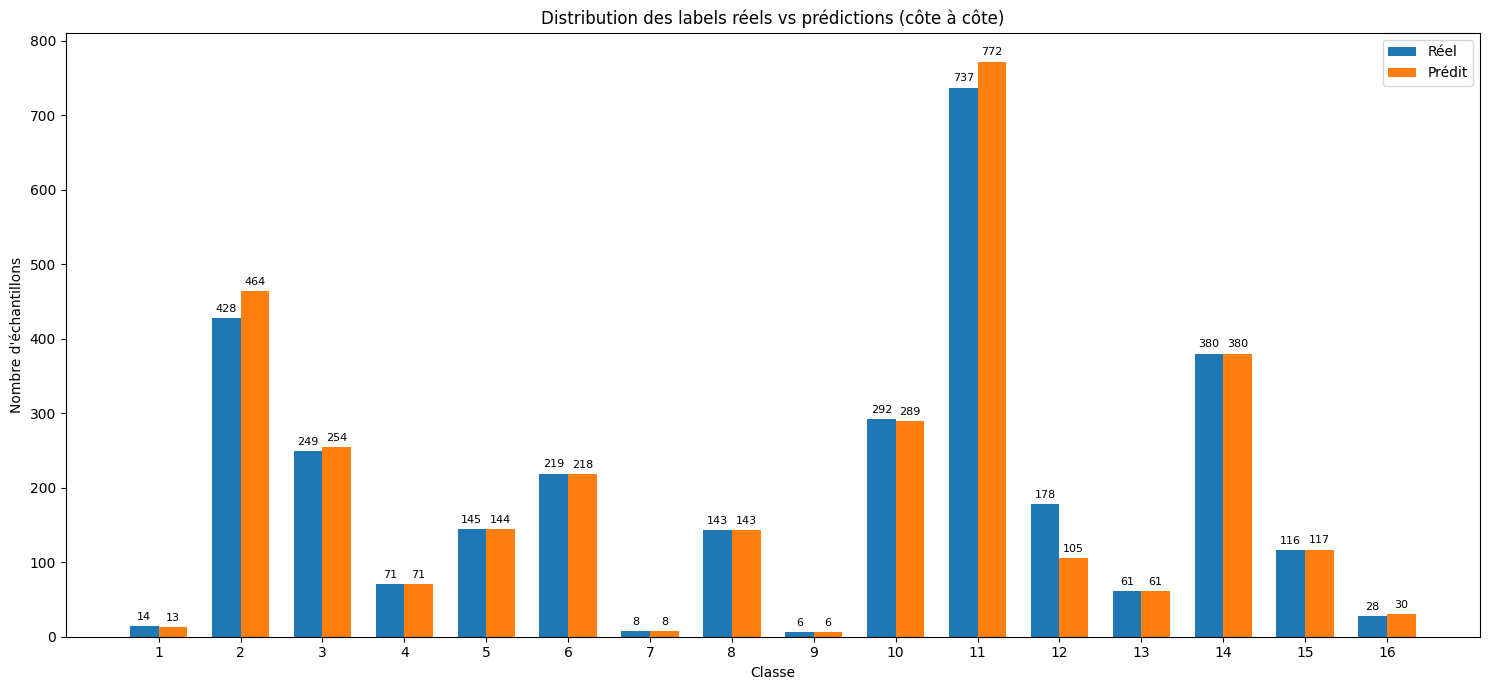

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Étape 1: Compter les occurrences pour chaque classe ---
# Counter est un outil très pratique pour cela
real_counts = Counter(all_labels)
pred_counts = Counter(all_preds)

# Extraire les classes et les comptes, en s'assurant que toutes les classes sont présentes
# (même celles avec un compte de zéro)
labels = np.arange(0, 16) # Nos classes vont de 0 à 15
real_values = [real_counts.get(i, 0) for i in labels]
pred_values = [pred_counts.get(i, 0) for i in labels]


# --- Étape 2: Préparer le graphique en barres ---
x = np.arange(len(labels))  # Les positions des groupes de barres sur l'axe X
width = 0.35  # La largeur des barres

fig, ax = plt.subplots(figsize=(15, 7))

# Créer les barres pour les données réelles et prédites
rects1 = ax.bar(x - width/2, real_values, width, label='Réel', color='tab:blue')
rects2 = ax.bar(x + width/2, pred_values, width, label='Prédit', color='tab:orange')

# --- Étape 3: Mettre en forme le graphique ---
ax.set_ylabel('Nombre d\'échantillons')
ax.set_xlabel('Classe')
ax.set_title('Distribution des labels réels vs prédictions (côte à côte)')
ax.set_xticks(x)
# Les labels des classes doivent correspondre à 1-16 pour la lisibilité
ax.set_xticklabels(np.arange(1, 17))
ax.legend()

# Ajouter des étiquettes de valeur au-dessus des barres (optionnel mais très pro)
ax.bar_label(rects1, padding=3, fontsize=8)
ax.bar_label(rects2, padding=3, fontsize=8)

fig.tight_layout()
plt.show()